In [ ]:
!unzip "/content/US_Accidents_March23.csv.zip"

Archive:  /content/US_Accidents_March23.csv.zip
  inflating: US_Accidents_March23.csv  


In [ ]:
!pip install ultralytics opencv-python tensorflow scikit-learn pandas numpy requests googlemaps

In [ ]:
import pandas as pd

df = pd.read_csv("/content/US_Accidents_March23.csv", nrows=1)
print(df.columns.tolist())

['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']


In [ ]:
import pandas as pd

df = pd.read_csv("/content/US_Accidents_March23.csv", nrows=5)
print(df.head())

    ID   Source  Severity           Start_Time             End_Time  \
0  A-1  Source2         3  2016-02-08 05:46:00  2016-02-08 11:00:00   
1  A-2  Source2         2  2016-02-08 06:07:59  2016-02-08 06:37:59   
2  A-3  Source2         2  2016-02-08 06:49:27  2016-02-08 07:19:27   
3  A-4  Source2         3  2016-02-08 07:23:34  2016-02-08 07:53:34   
4  A-5  Source2         2  2016-02-08 07:39:07  2016-02-08 08:09:07   

   Start_Lat  Start_Lng  End_Lat  End_Lng  Distance(mi)  ... Roundabout  \
0  39.865147 -84.058723      NaN      NaN          0.01  ...      False   
1  39.928059 -82.831184      NaN      NaN          0.01  ...      False   
2  39.063148 -84.032608      NaN      NaN          0.01  ...      False   
3  39.747753 -84.205582      NaN      NaN          0.01  ...      False   
4  39.627781 -84.188354      NaN      NaN          0.01  ...      False   

  Station   Stop Traffic_Calming Traffic_Signal Turning_Loop Sunrise_Sunset  \
0   False  False           False          F

In [ ]:
#Input Datasets

import os
import random
import numpy as np
import pandas as pd
import cv2
import requests

from sklearn.preprocessing import StandardScaler

TRAFFIC_VIDEO = "/content/dense_traffic.mp4"
DATASET_PATH = "/content/US_Accidents_March23.csv"
WEATHER_API_KEY = "f3972896faa46b57047f962f5563bd63"

if DATASET_PATH == "generate_synthetic" or not os.path.exists(DATASET_PATH):

    print("Using accident dataset")

    size = 50000
    density = np.random.randint(5, 150, size)
    visibility = np.random.uniform(0.5, 10, size)
    rainfall = np.random.uniform(0, 15, size)

    labels = np.where((density > 80) | (rainfall > 8), 1, 0)

else:

    print("Loading real dataset")

    df = pd.read_csv(DATASET_PATH, nrows=50000)

    visibility = df['Visibility(mi)'].fillna(10).values
    rainfall = df['Precipitation(in)'].fillna(0).values

    infra = (
        df['Traffic_Signal'].astype(int) +
        df['Crossing'].astype(int) +
        df['Junction'].astype(int)
    )

    density = np.where(infra > 0, 100, 30)
    labels = np.where(df['Severity'] >= 3, 1, 0)

X = np.column_stack((density, visibility, rainfall))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data Loaded & Preprocessed")

Loading real dataset
Data Loaded & Preprocessed


PART 2: MODEL TRAINING (KMEANS + KNN + ANN)

In [ ]:
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


# KMEANS
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
kmeans.fit(X_scaled)

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_scaled, labels)

# ANN
ann = Sequential([
    tf.keras.layers.Input(shape=(3,)),
    Dense(16, activation='relu'),
    Dropout(0.1),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("\nANN TRAINING PIPELINE STARTED")

epochs = 10
loss_history = []

for epoch in range(epochs):

    history = ann.fit(
        X_scaled,
        labels,
        epochs=1,
        batch_size=64,
        verbose=0,
         validation_split=0.2
    )

    loss = history.history['loss'][0]
    loss_history.append(loss)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"  Loss: {loss:.4f}")
    print(f"  Status: Optimizing weights...")

train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print("\nANN PERFORMANCE")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

print("\nANN Training Completed Successfully")


ANN TRAINING PIPELINE STARTED
Epoch 1/10
  Loss: 0.6671
  Status: Optimizing weights...
Epoch 2/10
  Loss: 0.6627
  Status: Optimizing weights...
Epoch 3/10
  Loss: 0.6617
  Status: Optimizing weights...
Epoch 4/10
  Loss: 0.6610
  Status: Optimizing weights...
Epoch 5/10
  Loss: 0.6612
  Status: Optimizing weights...
Epoch 6/10
  Loss: 0.6609
  Status: Optimizing weights...
Epoch 7/10
  Loss: 0.6608
  Status: Optimizing weights...
Epoch 8/10
  Loss: 0.6608
  Status: Optimizing weights...
Epoch 9/10
  Loss: 0.6608
  Status: Optimizing weights...
Epoch 10/10
  Loss: 0.6608
  Status: Optimizing weights...

ANN PERFORMANCE
Training Accuracy: 0.6206
Validation Accuracy: 0.5283

ANN Training Completed Successfully


PART 3: FUZZY LOGIC

In [ ]:

def fuzzy_weather_risk(vis, rain):

    risk = 0.0

    if vis < 2:
        risk += 0.5
    elif vis < 5:
        risk += 0.3
    else:
        risk += 0.1

    if rain > 10:
        risk += 0.4
    elif rain > 3:
        risk += 0.2

    return min(risk, 1.0)

print("Fuzzy Logic Ready")

Fuzzy Logic Ready


PART 4: TRAFFIC + YOLO + MAPS INPUT

In [ ]:
from ultralytics import YOLO

class Telemetry:

    def get_traffic(self):

        if os.path.exists(TRAFFIC_VIDEO):
            try:
                model = YOLO("yolov8n.pt")

                cap = cv2.VideoCapture(TRAFFIC_VIDEO)
                cap.set(cv2.CAP_PROP_POS_FRAMES, random.randint(0, 300))

                ret, frame = cap.read()
                cap.release()

                if not ret:
                    return random.randint(20, 100)

                results = model(frame, classes=[2,3,5,7], verbose=False)
                return len(results[0].boxes)

            except:
                return random.randint(30, 90)

        return random.randint(20, 90)

    def get_weather(self):
        try:
            url = f"http://api.openweathermap.org/data/2.5/weather?q=Karachi&appid={WEATHER_API_KEY}"
            data = requests.get(url).json()

            vis = data.get("visibility", 10000) / 1000
            rain = data.get("rain", {}).get("1h", 0.0)

            return vis, rain

        except:
            return random.uniform(2, 10), random.uniform(0, 10)

    def get_routes(self):
        return [
            {"name": "Highway", "dist": 12.4},
            {"name": "City Road", "dist": 14.2},
            {"name": "Bypass", "dist": 18.5}
        ]

print("Input Modules Ready")

Input Modules Ready


PART 5: DECISION MAKING (KNN + ANN + A*)

In [ ]:

def a_star(routes, risk):

    best = None
    best_cost = float("inf")
    logs = []

    for r in routes:

        g = r["dist"]
        h = (g * risk * 5)

        f = g + h

        logs.append({
            "route": r["name"],
            "g": g,
            "h": round(h, 2),
            "f": round(f, 2)
        })

        if f < best_cost:
            best_cost = f
            best = r["name"]

    return best, logs


def decision_engine(traffic, vis, rain, routes):

    input_vec = scaler.transform([[traffic, vis, rain]])

    ann_risk = float(ann.predict(input_vec, verbose=0)[0][0])
    knn_risk = knn.predict(input_vec)[0]
    fuzzy_risk = fuzzy_weather_risk(vis, rain)

    final_risk = (ann_risk * 0.6) + (fuzzy_risk * 0.4)

    best_route, logs = a_star(routes, final_risk)

    return best_route, logs, final_risk

print("Decision Engine Ready")

Decision Engine Ready


PART 6: SYSTEM EXECUTION

In [ ]:

telemetry = Telemetry()

for i in range(1, 6):

    traffic = telemetry.get_traffic()
    vis, rain = telemetry.get_weather()
    routes = telemetry.get_routes()

    best, logs, risk = decision_engine(traffic, vis, rain, routes)

    print(f"\nFRAME {i}")
    print("Traffic:", traffic)
    print("Risk:", round(risk, 2))

    if risk > 0.6:
        print("HIGH RISK ALERT")
    else:
        print("NORMAL CONDITIONS")

    print("\nRoutes:")
    for r in logs:
        print(r)

    print("Selected Route:", best)




FRAME 1
Traffic: 30
Risk: 0.28
NORMAL CONDITIONS

Routes:
{'route': 'Highway', 'g': 12.4, 'h': 17.48, 'f': 29.88}
{'route': 'City Road', 'g': 14.2, 'h': 20.02, 'f': 34.22}
{'route': 'Bypass', 'g': 18.5, 'h': 26.08, 'f': 44.58}
Selected Route: Highway

FRAME 2
Traffic: 82
Risk: 0.25
NORMAL CONDITIONS

Routes:
{'route': 'Highway', 'g': 12.4, 'h': 15.8, 'f': 28.2}
{'route': 'City Road', 'g': 14.2, 'h': 18.1, 'f': 32.3}
{'route': 'Bypass', 'g': 18.5, 'h': 23.58, 'f': 42.08}
Selected Route: Highway

FRAME 3
Traffic: 80
Risk: 0.26
NORMAL CONDITIONS

Routes:
{'route': 'Highway', 'g': 12.4, 'h': 15.85, 'f': 28.25}
{'route': 'City Road', 'g': 14.2, 'h': 18.15, 'f': 32.35}
{'route': 'Bypass', 'g': 18.5, 'h': 23.64, 'f': 42.14}
Selected Route: Highway

FRAME 4
Traffic: 55
Risk: 0.28
NORMAL CONDITIONS

Routes:
{'route': 'Highway', 'g': 12.4, 'h': 17.1, 'f': 29.5}
{'route': 'City Road', 'g': 14.2, 'h': 19.58, 'f': 33.78}
{'route': 'Bypass', 'g': 18.5, 'h': 25.51, 'f': 44.01}
Selected Route: Highwa

KNN VISUALIZATION

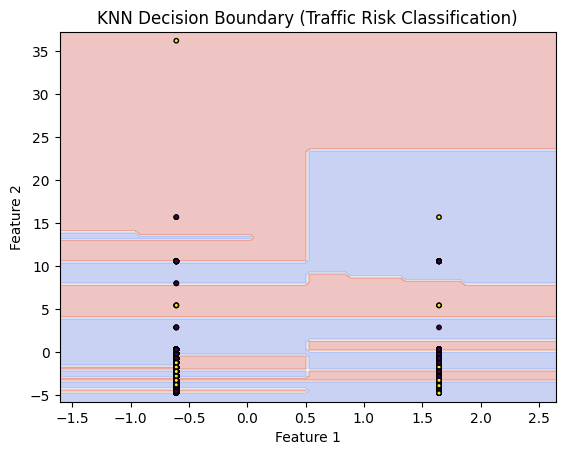

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 100),
    np.linspace(y_min, y_max, 100)
)

grid = np.c_[xx.ravel(), yy.ravel(), np.zeros_like(xx.ravel())]
Z = knn.predict(grid)
Z = Z.reshape(xx.shape)

plt.figure()

plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=labels,
    edgecolor='k',
    s=10
)

plt.title("KNN Decision Boundary (Traffic Risk Classification)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

KMEANS CLUSTERING VISUAL

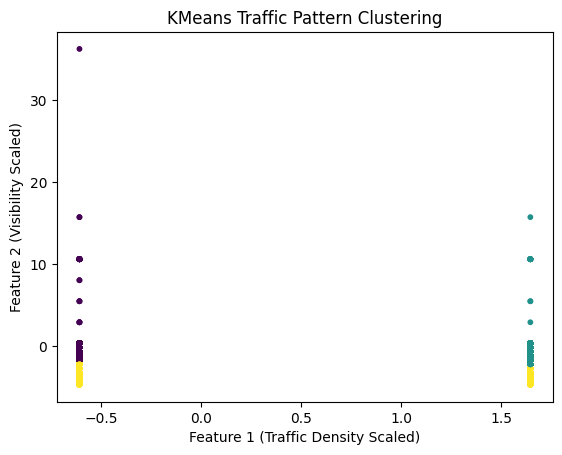

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=kmeans.labels_,
    cmap='viridis',
    s=10
)

plt.title("KMeans Traffic Pattern Clustering")
plt.xlabel("Feature 1 (Traffic Density Scaled)")
plt.ylabel("Feature 2 (Visibility Scaled)")

plt.show()

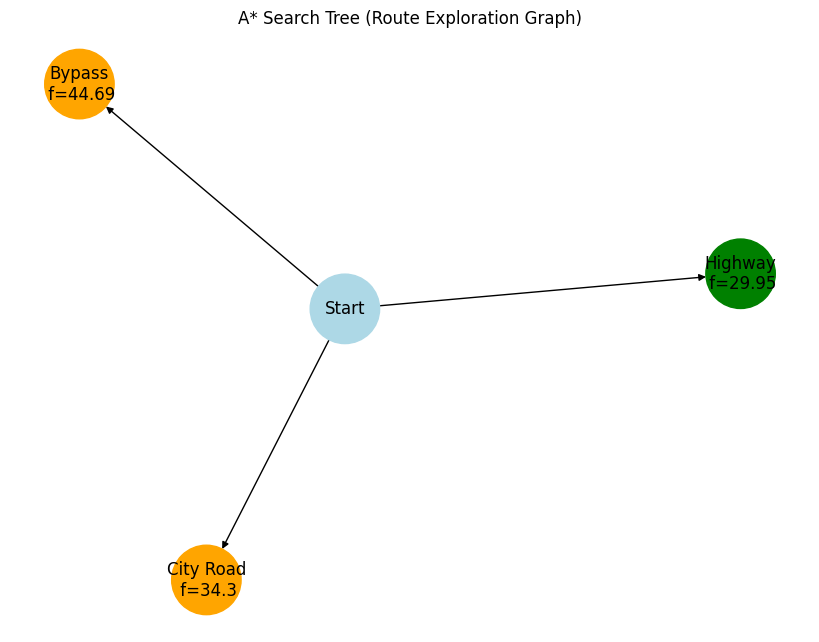

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

G.add_node("Start")

routes = {
    "Highway": {"g": 12.4, "h": 17.55, "f": 29.95},
    "City Road": {"g": 14.2, "h": 20.1, "f": 34.3},
    "Bypass": {"g": 18.5, "h": 26.19, "f": 44.69}
}

# Build tree
for r, v in routes.items():

    node_label = f"{r}\n f={v['f']}"

    G.add_node(node_label)
    G.add_edge("Start", node_label)

best_route = min(routes.items(), key=lambda x: x[1]["f"])[0]

best_node = f"{best_route}\n f={routes[best_route]['f']}"

plt.figure(figsize=(8,6))
pos = nx.spring_layout(G, seed=42)

node_colors = []
for node in G.nodes():
    if node == best_node:
        node_colors.append("green")
    elif node == "Start":
        node_colors.append("lightblue")
    else:
        node_colors.append("orange")

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=node_colors,
    node_size=2500,
    arrows=True
)

plt.title("A* Search Tree (Route Exploration Graph)")
plt.show()